# Etape 4 - Variations stylistiques et signal de genre

Ce notebook examine si le sexe des candidats est associe a des differences stylistiques dans les professions de foi, independamment de l'appartenance partisane. On suit un pipeline en quatre etapes : extraction de features stylistiques interpretables, analyse descriptive et tests non-parametriques, regression OLS pour controler l'effet du parti, et enfin une classification supervisee pour evaluer la predictibilite du genre a partir du style seul.

Une mise en garde importante s'impose d'emblee : le corpus presente un desequilibre marque entre hommes (environ 88 %) et femmes (environ 12 %). Toutes les analyses en tiennent compte explicitement, via des corrections pour tests multiples et l'utilisation de poids de classe dans la classification.

## 0. Imports

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import spacy
from scipy import stats
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

DATA_DIR    = Path("../data")
PROC_DIR    = DATA_DIR / "processed"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("Librairies chargees.")

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Librairies chargees.


## 1. Chargement des donnees

In [2]:
df = pd.read_csv(PROC_DIR / "corpus_1993.csv")

# On garde uniquement les candidats dont le sexe est renseigne
df_gendered = df[df["titulaire-sexe"].isin(["homme", "femme"])].copy().reset_index(drop=True)

n_h = (df_gendered["titulaire-sexe"] == "homme").sum()
n_f = (df_gendered["titulaire-sexe"] == "femme").sum()

print(f"Corpus total          : {len(df):,}")
print(f"Corpus avec genre     : {len(df_gendered):,}")
print(f"  Hommes              : {n_h:,}")
print(f"  Femmes              : {n_f:,}")
print(f"  Part des femmes     : {n_f / (n_h + n_f) * 100:.1f}%")

Corpus total          : 5,698
Corpus avec genre     : 5,060
  Hommes              : 4,424
  Femmes              : 636
  Part des femmes     : 12.6%


## 2. Extraction des features stylistiques

On calcule dix indicateurs stylistiques par document, en s'appuyant sur le pipeline spaCy pour la segmentation en phrases et les annotations morphosyntaxiques. Ces features sont choisies pour leur interpretabilite et pour couvrir des dimensions complementaires du style : longueur et complexite syntaxique, richesse lexicale, usage des pronoms et des modaux, lisibilite.

Le MSTTR (Mean Segmental Type-Token Ratio) a deja ete calcule dans le notebook 01 et est directement recupere depuis le fichier CSV. L'extraction spaCy sur l'ensemble du corpus prend environ 3 minutes sur CPU.

In [3]:
try:
    nlp = spacy.load("fr_core_news_md")
except OSError:
    nlp = spacy.load("fr_core_news_sm")

PRON_1SG = {"je", "j", "me", "moi", "mon", "ma", "mes"}
PRON_1PL = {"nous", "notre", "nos", "on"}
MODAUX   = {"devoir", "pouvoir", "falloir", "vouloir", "savoir", "oser", "osons"}


def count_syllables(word):
    """Estimation du nombre de syllabes (comptage des voyelles)."""
    return max(1, len([c for c in word.lower() if c in "aeeeiioouuuy"]))


def extract_style_features(text):
    """Extrait les features stylistiques d'un texte via spaCy."""
    doc = nlp(text)
    tokens_alpha = [t for t in doc if t.is_alpha]
    n_tokens = len(tokens_alpha) or 1

    sentences = list(doc.sents)
    sent_lens = [len([t for t in s if t.is_alpha]) for s in sentences]
    sent_lens = [l for l in sent_lens if l > 0]

    lemmas_lower = [t.lemma_.lower() for t in tokens_alpha]
    p1sg  = sum(1 for l in lemmas_lower if l in PRON_1SG)
    p1pl  = sum(1 for l in lemmas_lower if l in PRON_1PL)
    modal = sum(1 for l in lemmas_lower if l in MODAUX)
    n_adj = sum(1 for t in tokens_alpha if t.pos_ == "ADJ")

    word_lens = [len(t.text) for t in tokens_alpha]

    avg_sl  = np.mean(sent_lens) if sent_lens else 1
    avg_syl = np.mean([count_syllables(t.text) for t in tokens_alpha]) if tokens_alpha else 1
    # Formule Flesch adaptee au francais (approximation)
    flesch  = 207 - 1.015 * avg_sl - 73.6 * avg_syl

    return {
        "n_sentences"   : len(sent_lens),
        "mean_sent_len" : np.mean(sent_lens) if sent_lens else 0,
        "std_sent_len"  : np.std(sent_lens)  if len(sent_lens) > 1 else 0,
        "mean_word_len" : np.mean(word_lens) if word_lens else 0,
        "pron_1sg_rate" : p1sg  / n_tokens * 100,
        "pron_1pl_rate" : p1pl  / n_tokens * 100,
        "modal_rate"    : modal / n_tokens * 100,
        "adj_rate"      : n_adj / n_tokens * 100,
        "flesch_fr"     : flesch,
    }


print("Extraction des features stylistiques en cours...")
style_rows = [extract_style_features(text) for text in df_gendered["clean_text_lda"]]
df_style   = pd.DataFrame(style_rows)

# Recuperer le MSTTR calcule dans le notebook 01
df_style["msttr"] = df_gendered["msttr"].values

STYLE_FEATURES = list(df_style.columns)
for col in STYLE_FEATURES:
    df_gendered[col] = df_style[col].values

print(f"Features extraites ({len(STYLE_FEATURES)}) : {STYLE_FEATURES}")

Extraction des features stylistiques en cours...
Features extraites (10) : ['n_sentences', 'mean_sent_len', 'std_sent_len', 'mean_word_len', 'pron_1sg_rate', 'pron_1pl_rate', 'modal_rate', 'adj_rate', 'flesch_fr', 'msttr']


## 3. Analyse descriptive

On commence par comparer les distributions de chaque feature entre hommes et femmes, d'abord via les statistiques sommaires, puis visuellement avec des violin plots qui montrent la forme complete des distributions et pas seulement les moyennes.

In [4]:
desc = (
    df_gendered.groupby("titulaire-sexe")[STYLE_FEATURES]
    .agg(["mean", "std", "median"])
    .round(3)
)
print("Statistiques descriptives par sexe :")
display(desc)

Statistiques descriptives par sexe :


n_sentences               mean_sent_len                    \
                      mean    std median          mean      std   median   
titulaire-sexe                                                             
femme                5.566  5.253    5.0       179.564  171.889  121.500   
homme                5.932  6.525    5.0       169.542  166.149  119.243   

               std_sent_len                   mean_word_len  ... modal_rate  \
                       mean      std   median          mean  ...     median   
titulaire-sexe                                               ...              
femme               191.310  136.316  157.390         5.015  ...      0.823   
homme               182.295  120.723  160.749         4.989  ...      0.846   

               adj_rate                flesch_fr                   msttr  \
                   mean    std  median      mean      std  median   mean   
titulaire-sexe                                                             
femme            10.281  1.917  10.383  -131.719  172.206 -80.865  0.874   
homme            10.239  1.935  10.025  -120.365  167.518 -68.525  0.873   

                              
                  std median  
titulaire-sexe                
femme           0.039  0.878  
homme           0.040  0.877  

[2 rows x 30 columns]

### 3.1 Violin plots par feature

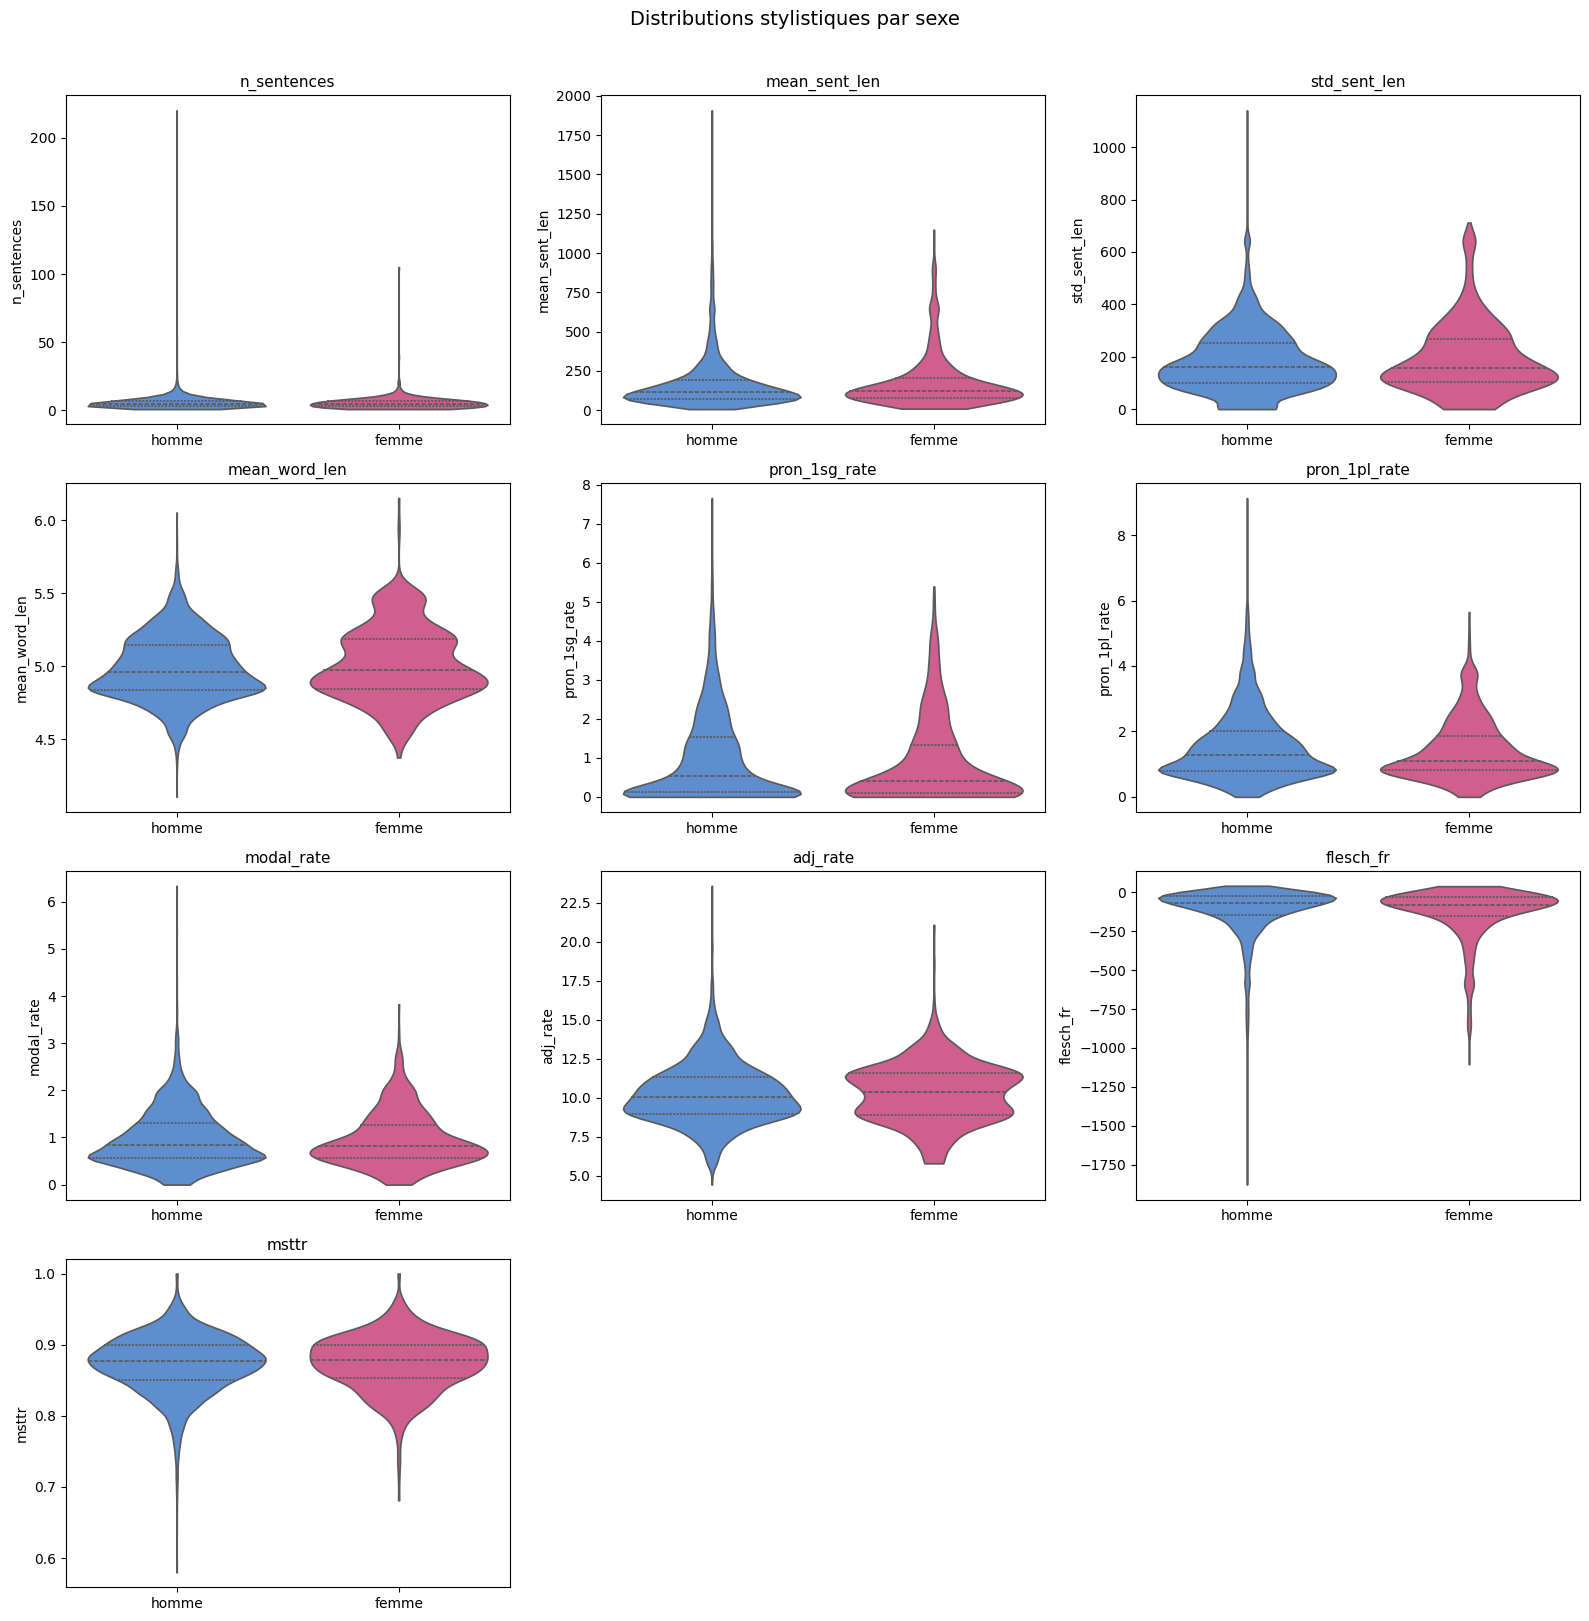

In [5]:
n_feat = len(STYLE_FEATURES)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

palette = {"homme": "#4C8BE2", "femme": "#E24C8B"}

for ax, feat in zip(axes, STYLE_FEATURES):
    sns.violinplot(
        data=df_gendered, x="titulaire-sexe", y=feat,
        palette=palette, ax=ax, inner="quartile", cut=0
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")

for ax in axes[n_feat:]:
    ax.set_visible(False)

plt.suptitle("Distributions stylistiques par sexe", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_style_violins.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Tests de Mann-Whitney U avec correction de Bonferroni

Pour chaque feature, on applique un test de Mann-Whitney U (non-parametrique, robuste aux distributions non normales). On corrige le seuil de significativite par la methode de Bonferroni : alpha ajuste = 0.05 / nombre de features. Cela evite les faux positifs dus aux comparaisons multiples. On calcule egalement la taille d'effet r = Z / sqrt(N) pour evaluer l'importance pratique des differences observees.

In [6]:
alpha_bonf = 0.05 / len(STYLE_FEATURES)
results = []

for feat in STYLE_FEATURES:
    h = df_gendered[df_gendered["titulaire-sexe"] == "homme"][feat].dropna()
    f = df_gendered[df_gendered["titulaire-sexe"] == "femme"][feat].dropna()
    stat, p = stats.mannwhitneyu(h, f, alternative="two-sided")

    n = len(h) + len(f)
    z = (stat - len(h) * len(f) / 2) / np.sqrt(len(h) * len(f) * (n + 1) / 12)
    r = abs(z) / np.sqrt(n)

    results.append({
        "feature"    : feat,
        "mean_H"     : h.mean(), "mean_F": f.mean(),
        "diff_F_H"   : f.mean() - h.mean(),
        "U_stat"     : stat, "p_value": p,
        "effect_r"   : r,
        "significant": p < alpha_bonf
    })

df_tests = pd.DataFrame(results).sort_values("p_value")
print(f"Seuil Bonferroni : alpha = {alpha_bonf:.4f}\n")
display(df_tests.round(5))

Seuil Bonferroni : alpha = 0.0050



,feature,mean_H,mean_F,diff_F_H,U_stat,p_value,effect_r,significant
4,pron_1sg_rate,0.97173,0.85255,-0.11918,1496650.0,0.00873,0.03665,False
5,pron_1pl_rate,1.53821,1.39959,-0.13862,1494743.0,0.01071,0.03588,False
8,flesch_fr,-120.36452,-131.71866,-11.35414,1476966.0,0.04176,0.02862,False
3,mean_word_len,4.98871,5.01452,0.02581,1337999.5,0.04570,0.02809,False
7,adj_rate,10.23940,10.28120,0.04180,1348099.5,0.08820,0.02397,False
1,mean_sent_len,169.54228,179.56388,10.02159,1355780.5,0.13835,0.02083,False
0,n_sentences,5.93196,5.56604,-0.36592,1454840.0,0.16116,0.01959,False
2,std_sent_len,182.29467,191.30952,9.01486,1386750.5,0.55989,0.00820,False
6,modal_rate,0.97185,0.95320,-0.01865,1422919.0,0.64051,0.00657,False
9,msttr,0.87301,0.87401,0.00100,1390792.5,0.64136,0.00655,False


### 3.3 Regression OLS avec controle du parti

Les differences observees pourraient etre confondues par l'appartenance partisane : certains partis comptent davantage de femmes et pourraient egalement avoir un style propre. On isole l'effet du sexe en estimant pour chaque feature une regression OLS de la forme :

    feature ~ sexe_bin + C(parti)

Le coefficient de sexe_bin mesure l'ecart stylistique entre femmes et hommes toutes choses egales par ailleurs. Une valeur significativement non nulle apres controle du parti signalerait un veritable signal de genre independant des preferences partisanes.

In [7]:
df_reg = df_gendered.copy()
df_reg["sexe_bin"] = (df_reg["titulaire-sexe"] == "femme").astype(int)
df_reg.columns = df_reg.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)

reg_results = []
for feat in STYLE_FEATURES:
    feat_safe = feat.replace("-", "_")
    formula = f"{feat_safe} ~ sexe_bin + C(titulaire_soutien_simplifie)"
    try:
        model = smf.ols(formula=formula, data=df_reg).fit()
        coef  = model.params["sexe_bin"]
        pval  = model.pvalues["sexe_bin"]
        ci_l, ci_h = model.conf_int().loc["sexe_bin"]
        reg_results.append({
            "feature"    : feat,
            "coef_sexe"  : coef,
            "ci_low"     : ci_l, "ci_high": ci_h,
            "p_value"    : pval, "r2": model.rsquared,
            "significant": pval < 0.05
        })
    except Exception as e:
        print(f"  [ignoré] {feat} : {e}")

df_reg_res = pd.DataFrame(reg_results).sort_values("p_value")
print("Effet du sexe apres controle du parti (OLS) :\n")
display(df_reg_res.round(4))

Effet du sexe apres controle du parti (OLS) :



,feature,coef_sexe,ci_low,ci_high,p_value,r2,significant
3,mean_word_len,0.0190,0.0020,0.0360,0.0289,0.1840,True
5,pron_1pl_rate,-0.0742,-0.1582,0.0098,0.0834,0.0969,False
0,n_sentences,-0.4127,-0.9474,0.1220,0.1303,0.0131,False
4,pron_1sg_rate,0.0639,-0.0209,0.1487,0.1399,0.1905,False
7,adj_rate,-0.0211,-0.1747,0.1326,0.7880,0.1115,False
6,modal_rate,0.0047,-0.0424,0.0517,0.8463,0.1305,False
8,flesch_fr,-0.7144,-14.3088,12.8799,0.9179,0.0817,False
9,msttr,-0.0001,-0.0034,0.0033,0.9750,0.0253,False
2,std_sent_len,-0.0971,-9.6772,9.4829,0.9841,0.1452,False
1,mean_sent_len,-0.1258,-13.5864,13.3347,0.9854,0.0862,False


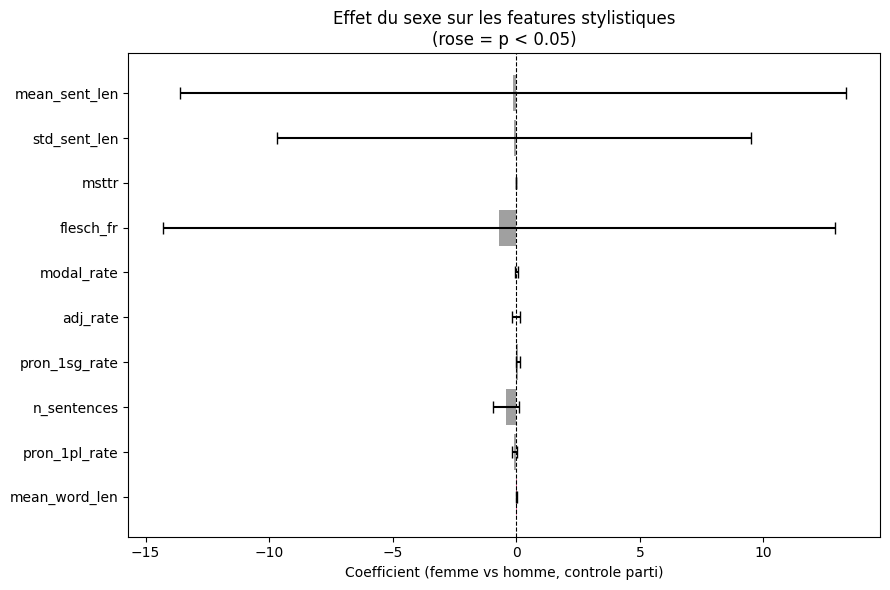

In [8]:
# Forest plot des coefficients
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E24C8B" if s else "#888888" for s in df_reg_res["significant"]]

ax.barh(df_reg_res["feature"], df_reg_res["coef_sexe"], color=colors, alpha=0.8)
ax.errorbar(
    df_reg_res["coef_sexe"], df_reg_res["feature"],
    xerr=[
        df_reg_res["coef_sexe"] - df_reg_res["ci_low"],
        df_reg_res["ci_high"]   - df_reg_res["coef_sexe"]
    ],
    fmt="none", color="black", capsize=4, lw=1.5
)
ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Coefficient (femme vs homme, controle parti)")
ax.set_title("Effet du sexe sur les features stylistiques\n(rose = p < 0.05)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_style_regression_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Classification supervisee

Pour evaluer dans quelle mesure le genre est predictible a partir du style seul, on entraine une regression logistique sur les features stylistiques. L'evaluation se fait en validation croisee stratifiee avec 5 folds, ce qui assure que le ratio hommes/femmes est preserve dans chaque fold.

Le parametre class_weight='balanced' pondere les observations inversement proportionnellement a la frequence de leur classe, ce qui evite que le modele ne se contente de predire systématiquement la classe majoritaire (hommes).

In [9]:
X = df_gendered[STYLE_FEATURES].values
y = (df_gendered["titulaire-sexe"] == "femme").astype(int).values

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Resultats de la validation croisee (5 folds) :")
for metric in ("accuracy", "f1_macro", "roc_auc"):
    scores = cross_val_score(clf, X, y, cv=cv, scoring=metric)
    print(f"  {metric:15s} : {scores.mean():.4f}  +/- {scores.std():.4f}")

baseline_acc = (y == 0).mean()
print(f"\n  Baseline (majorite) : {baseline_acc:.4f}")

Resultats de la validation croisee (5 folds) :
  accuracy        : 0.5103  +/- 0.0206
  f1_macro        : 0.4340  +/- 0.0155
  roc_auc         : 0.5599  +/- 0.0236

  Baseline (majorite) : 0.8743


Rapport de classification (test 20%) :
              precision    recall  f1-score   support

       homme       0.89      0.51      0.65       885
       femme       0.14      0.55      0.22       127

    accuracy                           0.51      1012
   macro avg       0.51      0.53      0.43      1012
weighted avg       0.79      0.51      0.59      1012



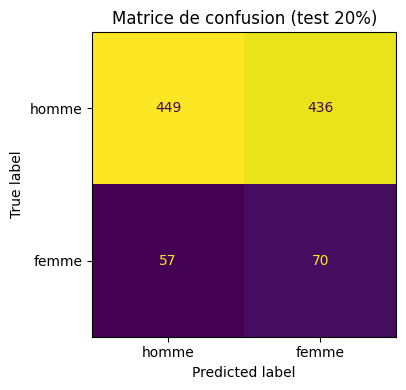

In [10]:
# Entrainement final et matrice de confusion sur le jeu de test (20 %)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

print("Rapport de classification (test 20%) :")
print(classification_report(y_te, y_pred, target_names=["homme", "femme"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=["homme", "femme"],
    colorbar=False, ax=ax
)
ax.set_title("Matrice de confusion (test 20%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

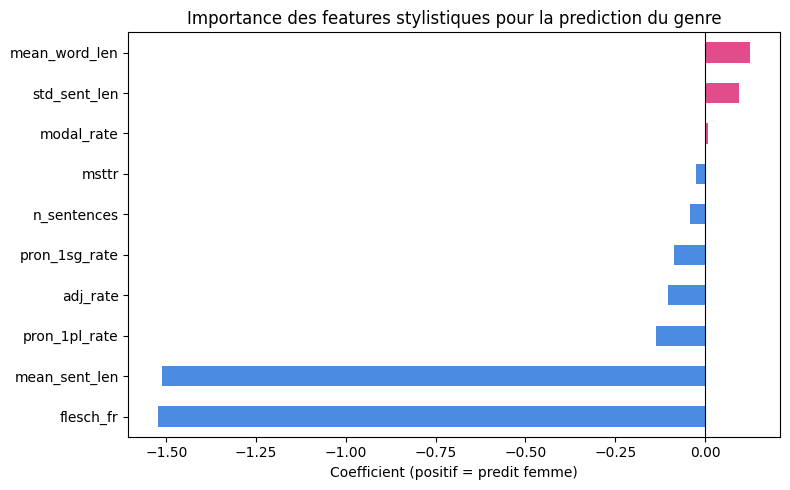

In [11]:
# Coefficients du modele logistique
coefs = clf.named_steps["lr"].coef_[0]
feat_imp = pd.Series(coefs, index=STYLE_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot.barh(ax=ax, color=["#E24C8B" if c > 0 else "#4C8BE2" for c in feat_imp])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (positif = predit femme)")
ax.set_title("Importance des features stylistiques pour la prediction du genre")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Synthese des resultats

In [12]:
sig_mw   = df_tests[df_tests["significant"]]["feature"].tolist()
sig_ols  = df_reg_res[df_reg_res["significant"]]["feature"].tolist()
sig_both = sorted(set(sig_mw) & set(sig_ols))

print("=" * 60)
print("SYNTHESE - Analyse stylistique par genre")
print("=" * 60)
print(f"\nFeatures differentes H/F (Mann-Whitney, Bonferroni) :")
print(f"  {sig_mw}")
print(f"\nFeatures significatives apres controle du parti (OLS) :")
print(f"  {sig_ols}")
print(f"\nFeatures robustes aux deux tests :")
print(f"  {sig_both}")
print(f"\nClassification (CV 5-fold) :")
print(f"  Baseline (majorite) : {baseline_acc:.3f}")

SYNTHESE - Analyse stylistique par genre

Features differentes H/F (Mann-Whitney, Bonferroni) :
  []

Features significatives apres controle du parti (OLS) :
  ['mean_word_len']

Features robustes aux deux tests :
  []

Classification (CV 5-fold) :
  Baseline (majorite) : 0.874


## 6. Sauvegarde

In [13]:
STYLE_COLS = ["id", "titulaire-sexe", "titulaire-soutien-simplifie"] + STYLE_FEATURES
df_gendered[STYLE_COLS].to_csv(PROC_DIR / "style_features_1993.csv", index=False)
print("Sauvegarde :", PROC_DIR / "style_features_1993.csv")

Sauvegarde : ../data/processed/style_features_1993.csv
